# Benchmark grid — model comparison across the test problems

The 4 defined mixed-variable test problems × 4 surrogate models (Standard LVGP, Heteroscedastic LVGP,
Separate GP, Categorical-kernel GP), all sharing the same SLHD initial design, acquisitions and sweep.
Reads `results/<function>/<model>/<acq>/nrep<NN>/seed<NN>.{npz,mat}` (python + matlab engines).

This generalizes the single-problem plots from `previous_ver/compare_methods.ipynb`: every view below is
**faceted over the test problems**, so it works for 1 or for all of them as the sweep fills in.

**Kernel: ml_gp_env.**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P
from utils.results import (GridResults, facet, heatmaps_by_function, final_regret_table,
                           coverage, runtime_table,
                           regret_heatmap,
                           problem_report, all_problem_reports, acquisition_facet, latent_space)

grid = GridResults.load('../results')
print('functions:', grid.functions())
print('models   :', grid.models())
print('cells    :', len(grid.runs))

functions: ['ackley_2d', 'branin_hetero', 'griewank_2d', 'sixhump_camel']
models   : ['categorical_kernel', 'heter_LVGP', 'separate_gp', 'standard_LVGP']
cells    : 5040


## The toggles

`GROUND_TRUTH` — how the **incumbent** (the "best design so far") is chosen, and what σ² means:

| | `True` | `False` |
|---|---|---|
| incumbent | argmin of the **noise-free** f | argmin of the **observed** replicate mean |
| σ² | the **true** noise variance σ(x,ℓ)² there | the **sample** variance of the replicates there |

This matters. The observed mean can dip *below* the true optimum f\* purely from noise (on branin,
`noisy_best = −3.16` against `f* = 0.465`), which makes a noisy "regret" look negative. `GROUND_TRUTH = True`
is the honest convergence measure; `False` shows what the optimizer actually saw.

`LOG_SCALE` applies to the regret and σ² convergence panels (not the value plot, which needs a linear axis
to show the f\* line).

In [2]:
GROUND_TRUTH = True         # <-- incumbent & sigma^2 by the noise-free f (see table above)
LOG_SCALE    = True         # <-- log y-axis on the regret / sigma^2 convergence panels
NOISE_AWARE_ONLY = True    # <-- per-acquisition facet: False = all 6 acqs, True = only HAEI/ANPEI/RAHBO
ACF, PARAM   = 'ei', float('nan')
N_REP        = 10           # replicates per design point: the sweep runs 3 and 10
FUNCS        = grid.functions()          # or e.g. ['branin_hetero', 'ackley_2d']
print(f'{len(FUNCS)} problems: {FUNCS}')


4 problems: ['ackley_2d', 'branin_hetero', 'griewank_2d', 'sixhump_camel']


## What the plots are averaging over
The sweep is long-running, so check the seed count behind each curve before reading too much into it.
`0` means that cell has not been computed yet.

In [3]:
coverage(grid, n_rep=N_REP)

model                       Categorical kernel  Heteroscedastic LVGP  \
function      acq                                                      
ackley_2d     ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
branin_hetero ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
griewank_2d   ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
sixhump_camel ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   

model                       Separate GP  Standard LVGP  
function      acq                                       
ackley_2d     ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
branin_hetero ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
griewank_2d   ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0  
sixhump_camel ANPEI(β=0.8)           30              0  
              EI                     30             30  
              HAEI(γ=0.5)            30              0  
              LCB                    30             30  
              PI                     30             30  
              RAHBO(α=0.5)           30              0

## Convergence — REGRET (value − f\*)
One panel per problem, the 4 models overlaid: mean ± standard error over seeds. Lower is better.
With `GROUND_TRUTH = True` regret is guaranteed ≥ 0, so the log axis is meaningful.

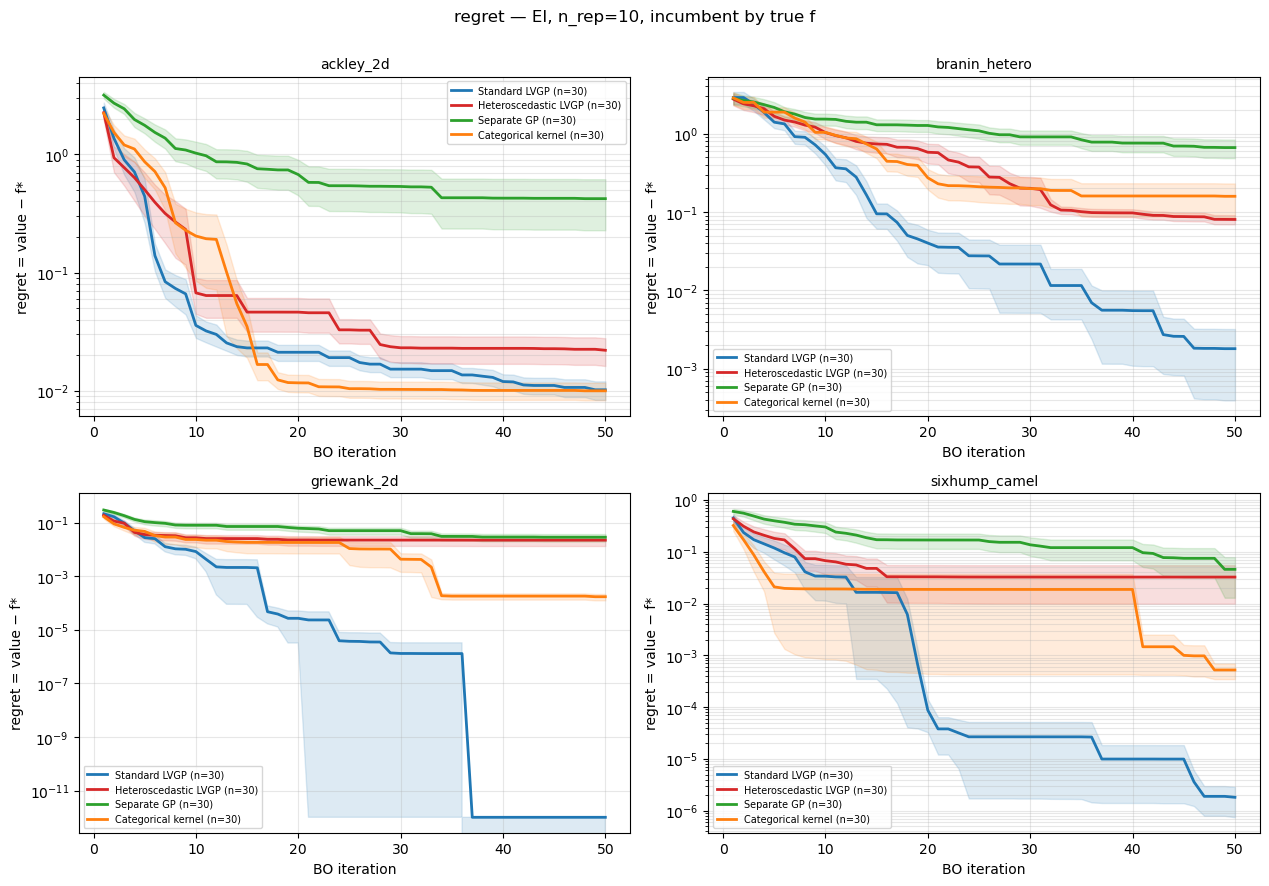

In [4]:
facet(grid, 'regret', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE);

## Convergence — VALUE, with the true optimum f\* as a horizontal line
The same runs on a linear axis, showing how close each model's best design gets to f\* (dashed grey).

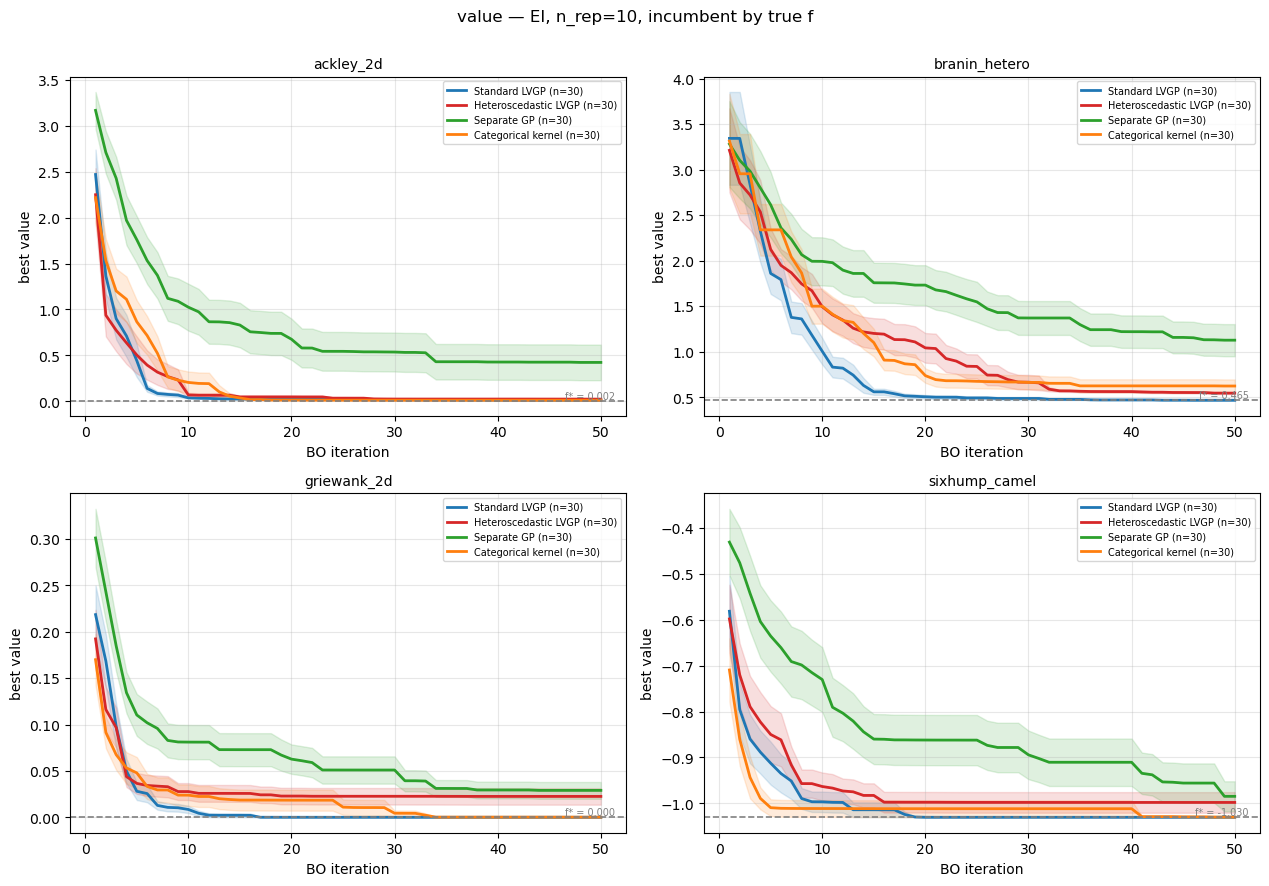

In [5]:
facet(grid, 'value', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=False);

## Noise variance σ² at the incumbent best design
The heteroscedastic question: *does the model end up recommending a design that sits in a noisy region?*
A noise-aware model should settle on a **lower σ²** incumbent, all else equal. With `GROUND_TRUTH = True`
this is the true σ(x,ℓ)² at the incumbent — not an estimate.

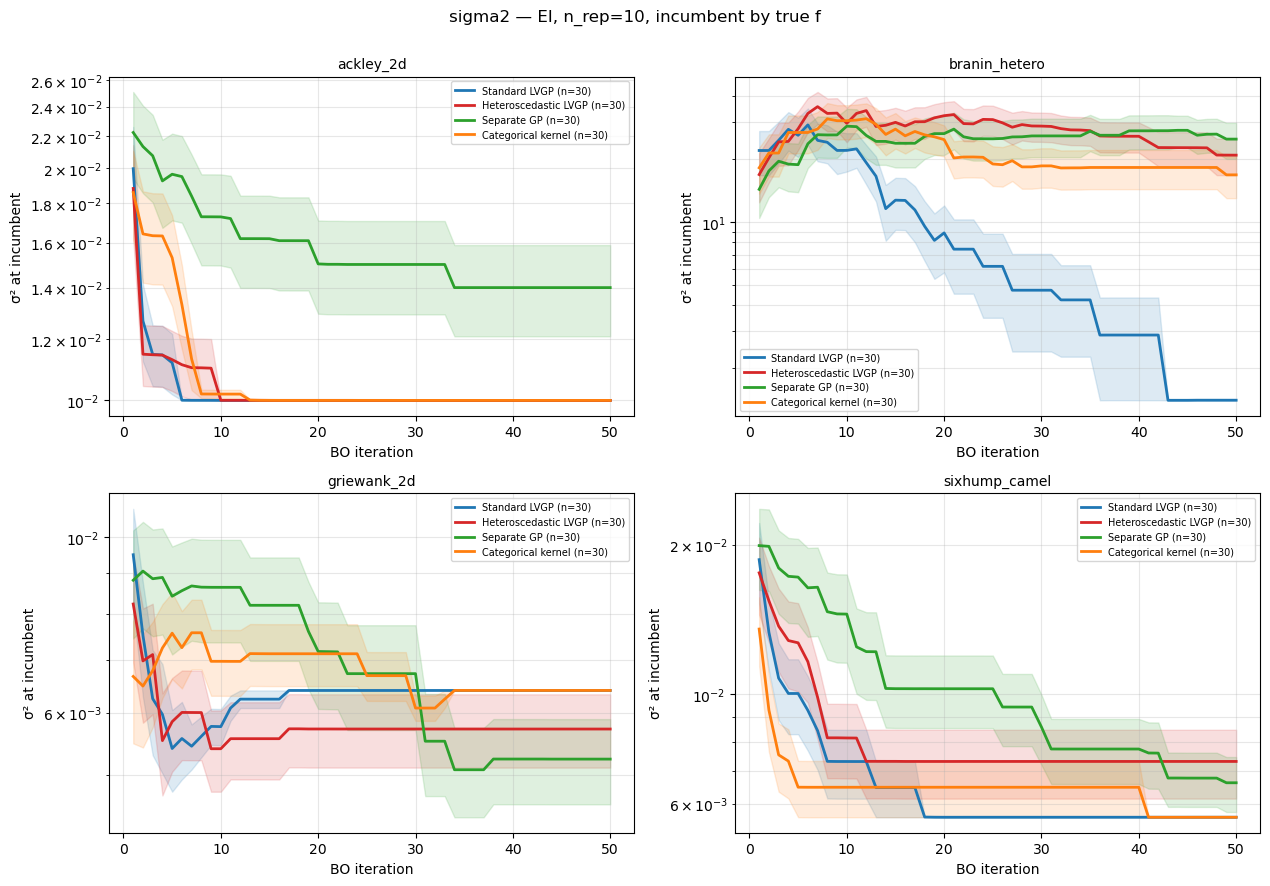

In [6]:
facet(grid, 'sigma2', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE);

## Summary heatmaps — acquisition × model, one per problem
Final regret for every acquisition actually present in the results. Acquisition rows with no data anywhere
are dropped, so there are no blank bands. Darker = better (lower regret).

Note `standard_LVGP` only supports the noise-blind acquisitions (ei/lcb/pi) by construction, so its
haei/anpei/rahbo entries are legitimately empty.

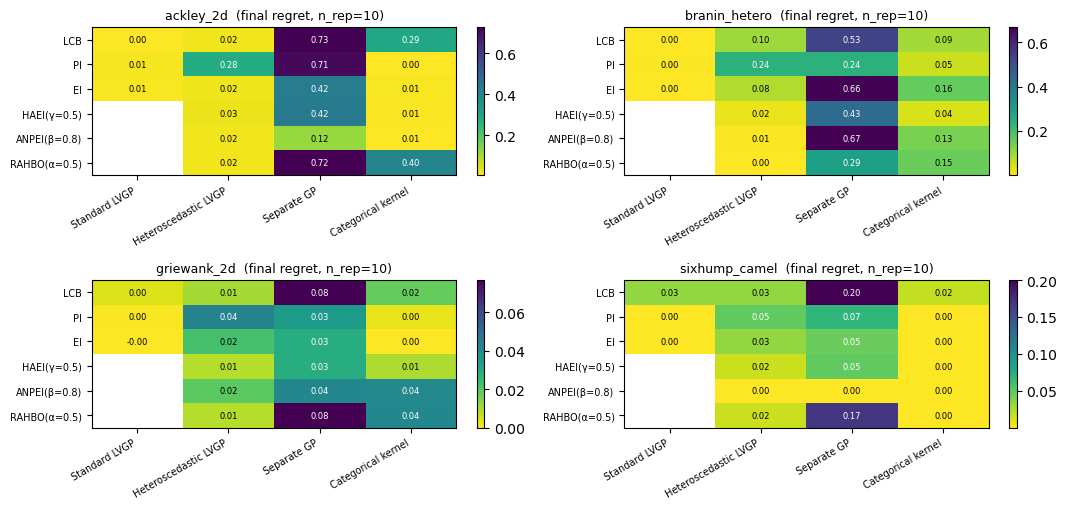

In [7]:
heatmaps_by_function(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH);

### Consolidated regret heatmap — every model / acquisition / problem in one figure
Same numbers as the per-problem heatmaps above, but stacked into a single view so you can scan
model-vs-acquisition across all problems at once. **Each cell is annotated with the mean final regret.**

Since the problems span orders of magnitude in regret, a shared raw color scale would be useless, so
**color is normalized within each row**: green = best model for that (problem, acquisition), red = worst.
The printed number is the true regret. Grey = no data (e.g. Standard LVGP has no noise-aware acquisitions).
Set `normalize='func'` to make colors comparable across a problem's acquisitions instead of per-row.

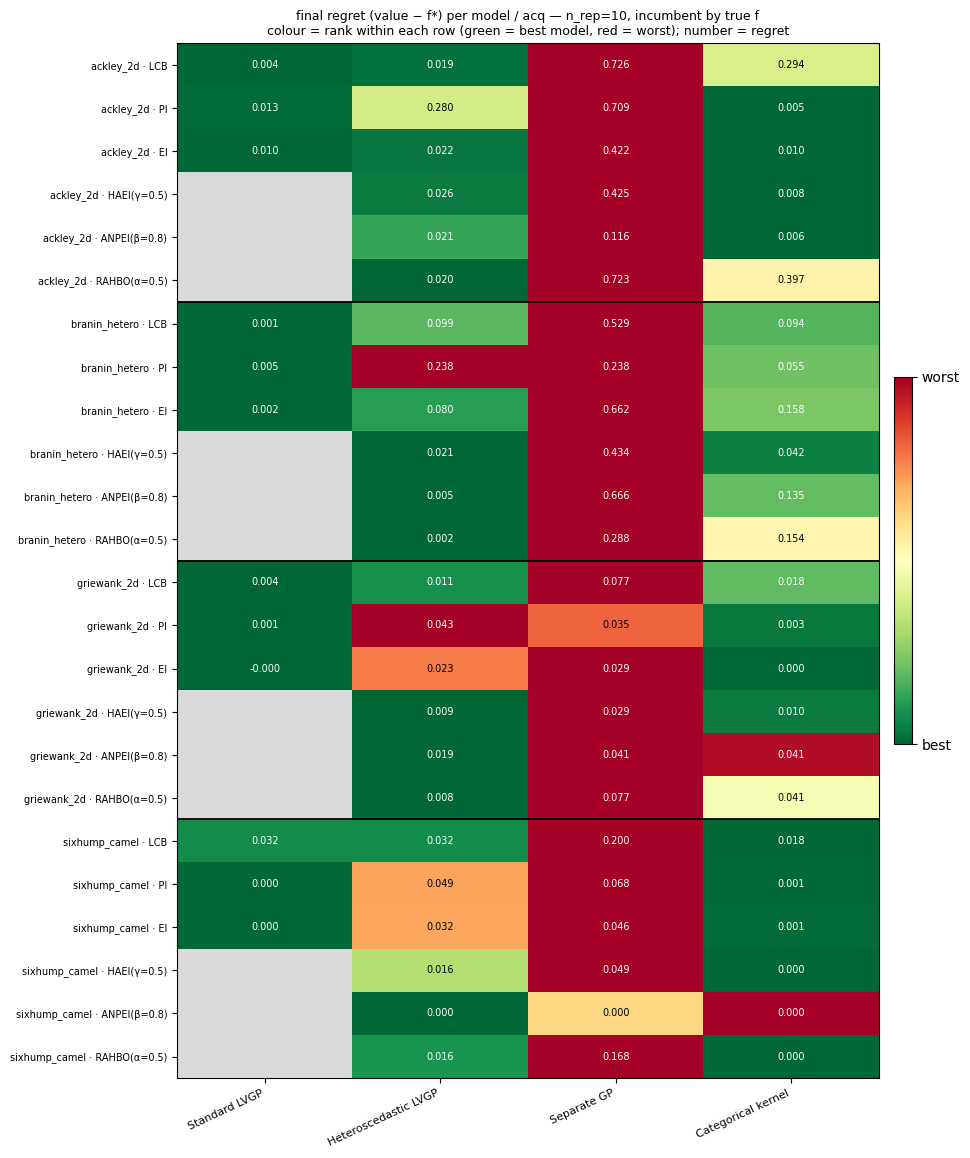

In [8]:
regret_heatmap(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH, normalize='row');

## Final-regret summary table (problem × model)

In [9]:
final_regret_table(grid, acf=ACF, param=PARAM, n_rep=N_REP)

,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
ackley_2d,0.010 ± 0.009,0.022 ± 0.031,0.422 ± 1.044,0.010 ± 0.010
branin_hetero,0.158 ± 0.390,0.080 ± 0.058,0.662 ± 0.950,0.002 ± 0.008
griewank_2d,0.000 ± 0.000,0.023 ± 0.048,0.029 ± 0.049,-0.000 ± 0.000
sixhump_camel,0.001 ± 0.001,0.032 ± 0.121,0.046 ± 0.177,0.000 ± 0.000


## Cost — mean wall-clock seconds per cell
The two MATLAB LVGP models dominate the sweep's runtime; the python GPs are an order of magnitude cheaper.

model,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
function,,,,
ackley_2d,73.4,410.9,18.8,396.5
branin_hetero,113.8,750.3,44.5,676.4
griewank_2d,54.2,312.7,17.7,312.6
sixhump_camel,58.2,312.9,20.5,305.3


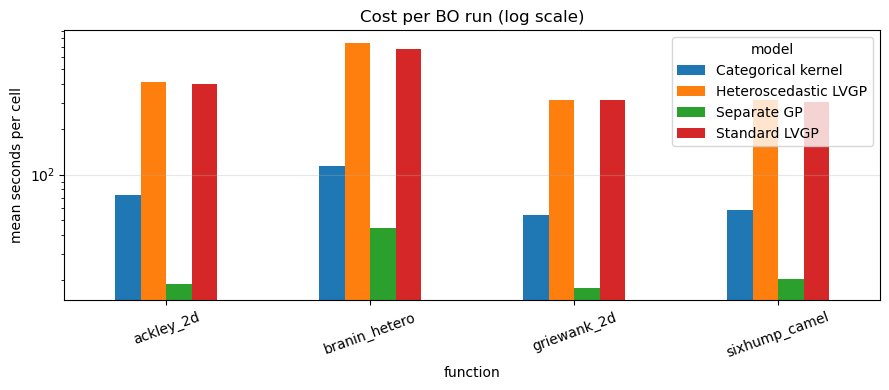

In [10]:
rt = runtime_table(grid)
display(rt)
ax = rt.plot(kind='bar', figsize=(9, 4), rot=20)
ax.set_ylabel('mean seconds per cell'); ax.set_yscale('log')
ax.set_title('Cost per BO run (log scale)'); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()

## Reading these plots

- **Regret vs σ²** are the two axes of the heteroscedastic trade-off. A model can win on regret while
  parking the incumbent in a high-noise region (bad if you must *deploy* that design), or vice versa.
- **`standard_LVGP` is noise-blind**: it never sees the replicate variance, so any advantage it shows on a
  noise-blind acquisition (ei/lcb/pi) is a fair comparison, but it cannot run haei/anpei/rahbo at all.
- Flip **`GROUND_TRUTH = False`** to see the optimizer's own view. Regret can go negative there — that is
  the noise, not a bug.
- Change `N_REP` between 3 and 10 to see how replicate count changes the variance estimate each model works
  from — the whole point of the heteroscedastic setup.

---
# Per-problem 

Everything above compares *across* problems. This section zooms into **one problem at a time** and
assesses every model / acquisition on it, with a consistent visual grammar so the encoding is learned once:

- **acquisition → colour**, **model → line style + marker** (in the panels that overlay both).

`problem_report(grid, function, ...)` produces two figures:

**overview** (6 panels)
1. the problem **landscape + initial DOE** — noise-free f(x1│level) per category, the true ±1σ noise band,
   the global optimum (★), and the shared SLHD design with its noisy replicates;
2. **regret** convergence (models, one acquisition);
3. **value** convergence with the f\* line;
4. **σ²** at the incumbent;
5. **all models × all acquisitions** on one regret axis (acq = colour, model = style);
6. **regret vs noise trade-off** — final regret against σ² at the incumbent; lower-left is the sweet spot.

**exploration** — the actual **sampling trajectory** of each model (x1 vs BO iteration, coloured by the
chosen categorical level, red line = the optimum's x1). This shows exploration-vs-exploitation and whether
a model locks onto the right category / x1.

`acf`/`param` fix the single acquisition used in panels 2–4 and the exploration figure; panels 5–6 sweep all
acquisitions.

> **How regret is computed here (and why it only steps *down*).**
> `regret(t) = [ best value among the first n_init + t sampled points ] − f*`, a **cumulative minimum**,
> so it is monotonic — it never rises. The visible steps are the best-so-far staircase (flat until a new
> best is sampled, then a drop), not noise. The `GROUND_TRUTH` toggle chooses what "best value" means:
> - **`True`** (default, and the case of interest here): the **noiseless** f(x, level) evaluated at each
>   sampled x — "sample the real value at the x locations, keep the best". Verified monotonic (0 up-jumps).
> - **`False`**: the **observed replicate mean** at each sampled x — "best across the mean".
>
> The only panel that legitimately rises and falls is **σ² at the incumbent** — that is not a best-so-far
> quantity: as the incumbent design changes, the noise level there can go up or down.

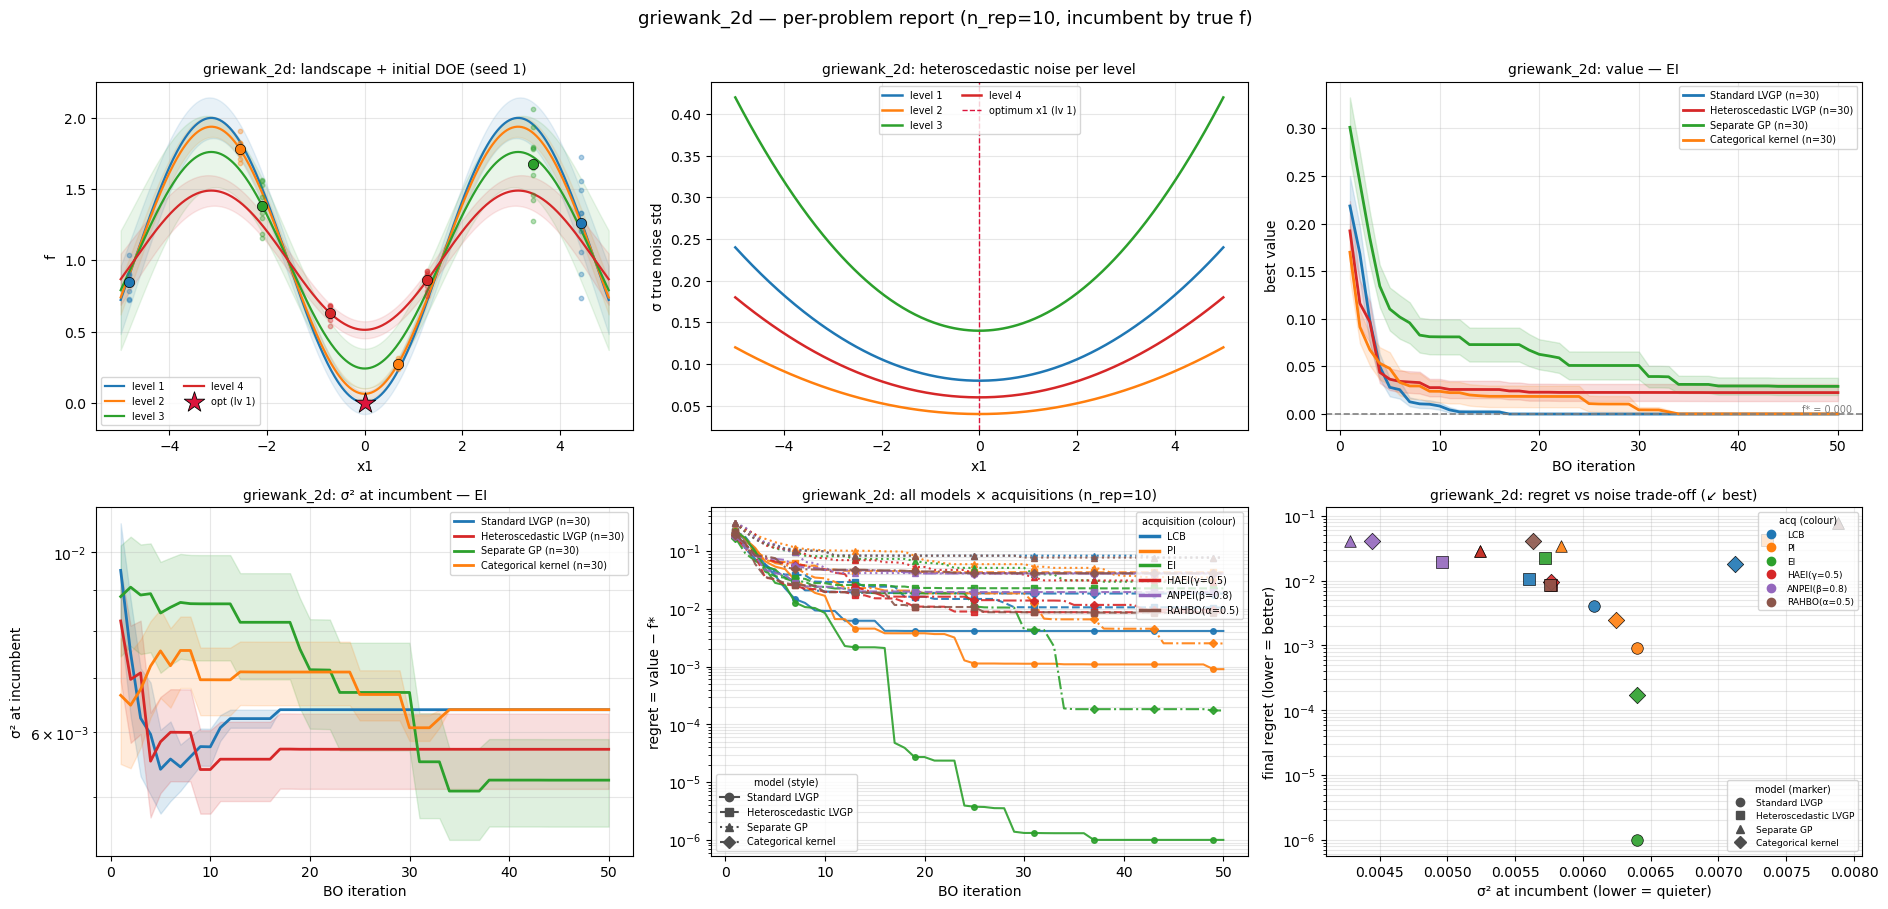

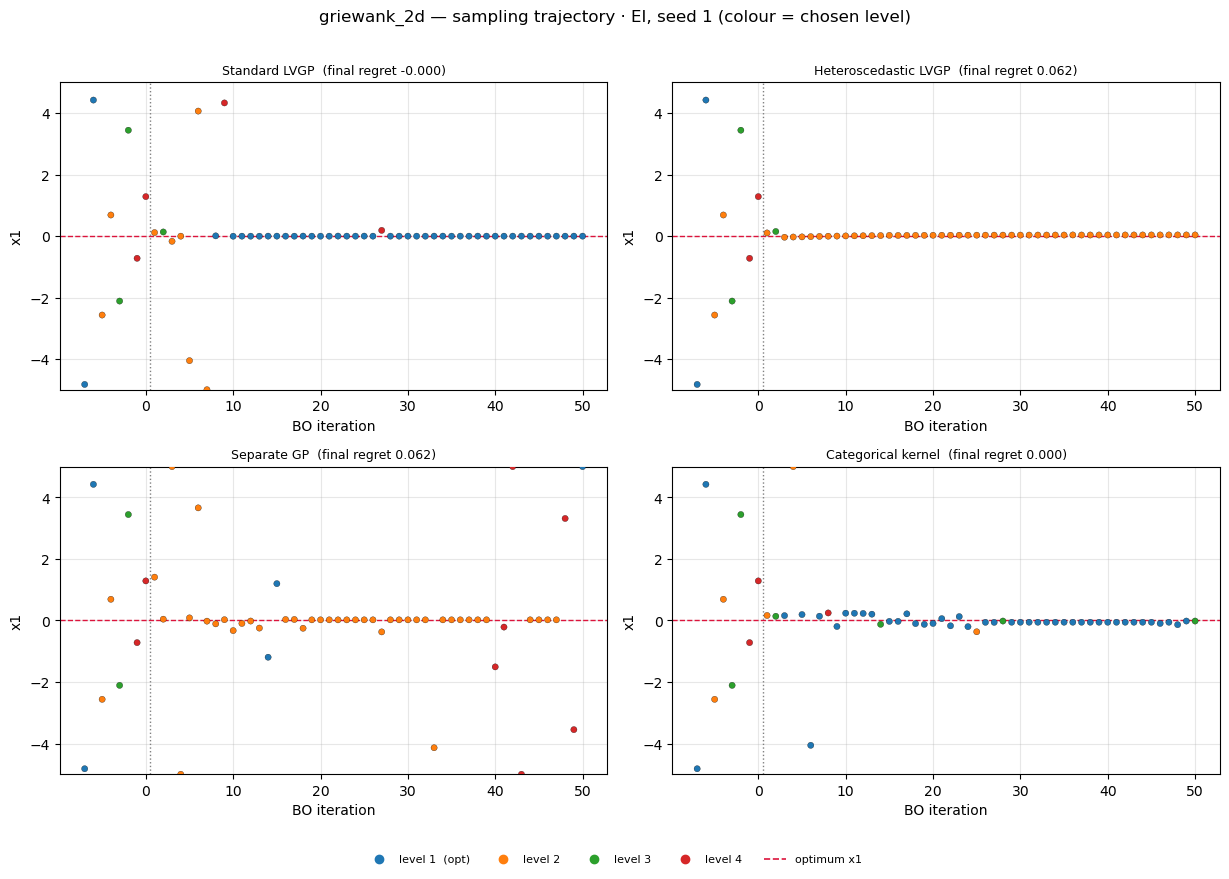

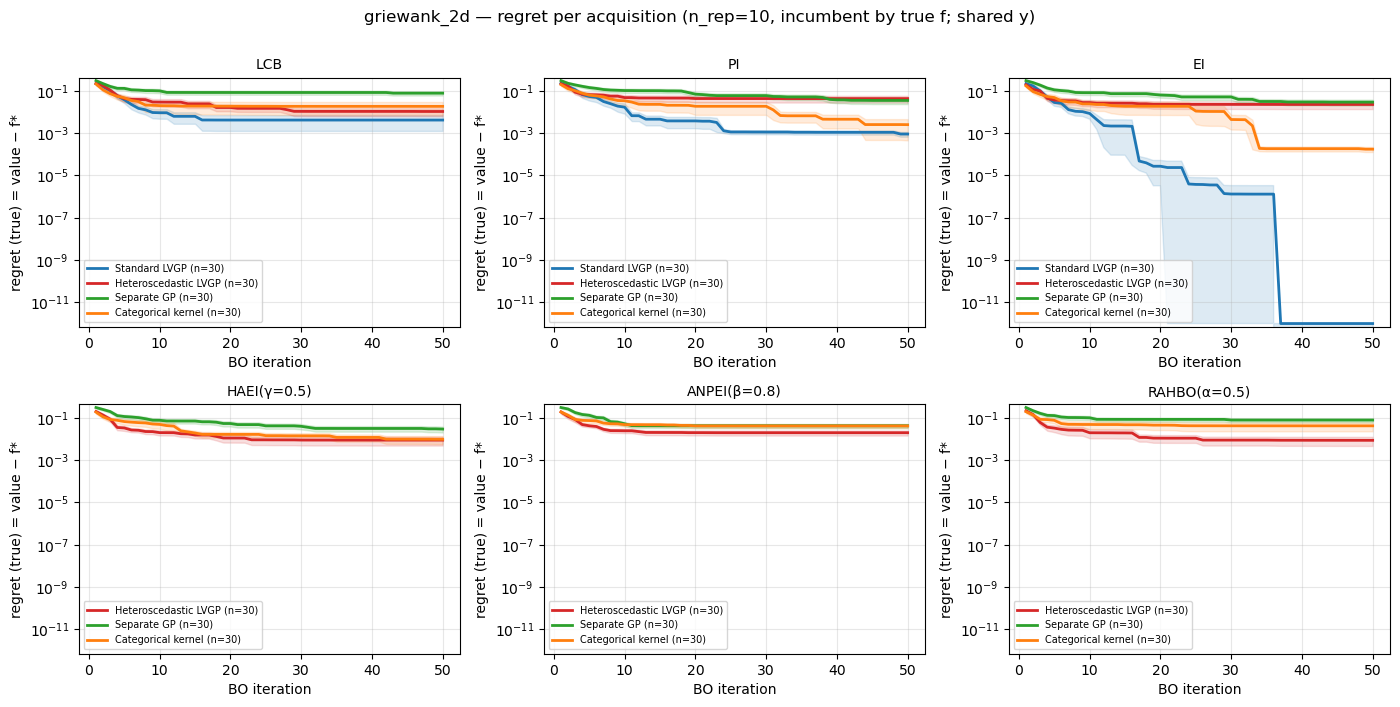

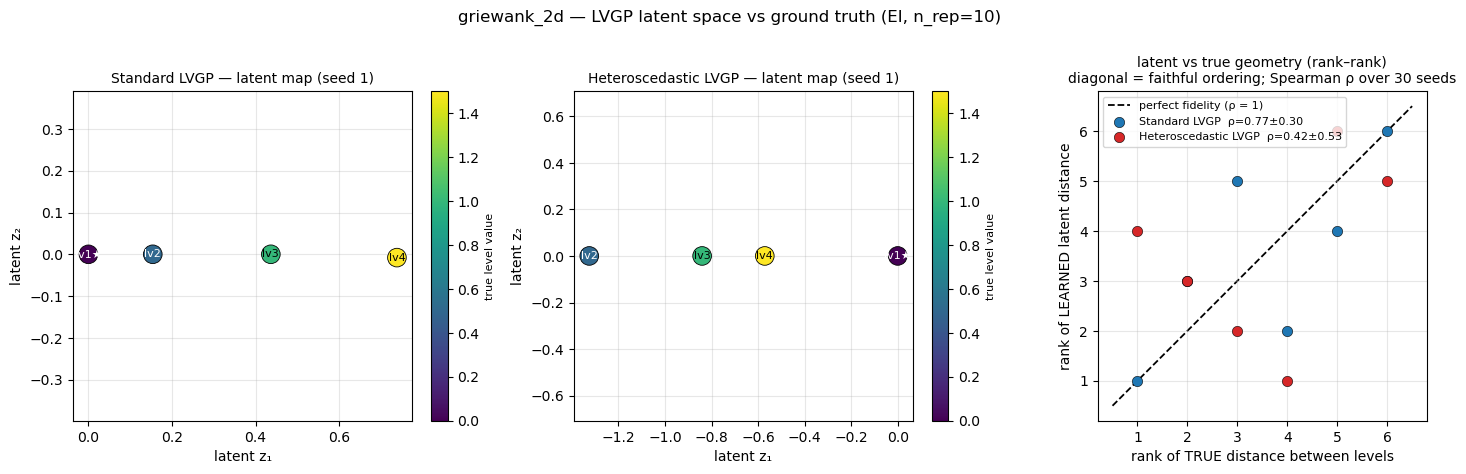

In [11]:
FOCUS = FUNCS[2]           # <-- pick any problem to inspect inline; e.g. 'ackley_2d'
problem_report(grid, FOCUS, acf=ACF, param=PARAM, n_rep=N_REP,
               ground_truth=GROUND_TRUTH, seed=1, show=True);

### Regret per acquisition — one panel per acquisition, models overlaid (shared y-axis)
For the focus problem: a panel for each acquisition, overlaying every model's regret convergence
(mean ± s.e., colour = model). **All panels share one y-range**, so you can compare acquisitions directly
— e.g. which acquisition drives a given model lowest. The bottom row (haei/anpei/rahbo) has no Standard
LVGP line because that model is noise-blind. This is also saved per problem as `by_acquisition.png`.

> Set `NOISE_AWARE_ONLY = True` in the toggles cell to show only the noise-aware acquisitions (HAEI, ANPEI, RAHBO) instead of all 6.


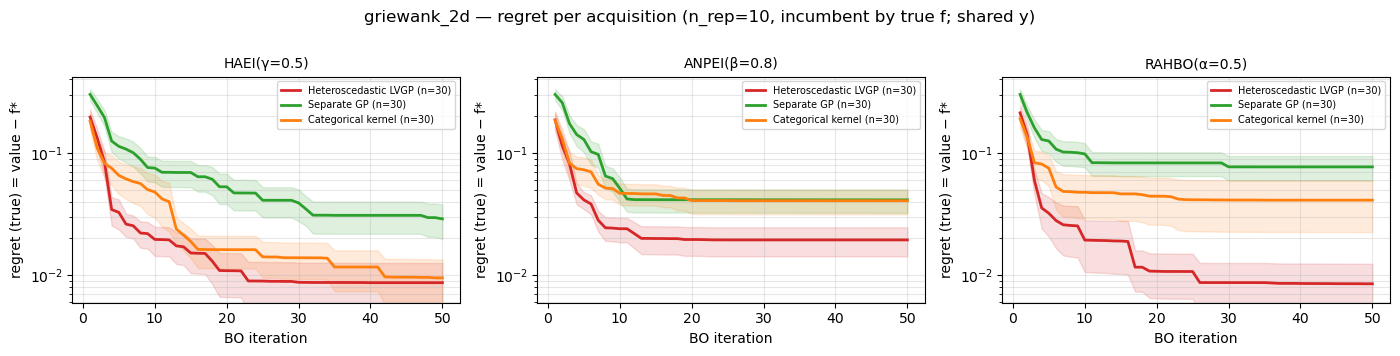

In [12]:
acquisition_facet(grid, FOCUS, n_rep=N_REP, ground_truth=GROUND_TRUTH,
                  share_y=True, noise_aware_only=NOISE_AWARE_ONLY);


### LVGP latent space vs ground truth
LVGP maps each categorical level to a 2-D latent point **z** — levels that behave similarly under the
true objective should land close together. Only the LVGP models expose this (`hyper.z`); the python GPs
have no such embedding.

- **Latent map** (one panel per LVGP model, one seed): each level's learned z, annotated (★ = optimal
  level), coloured by its **true underlying value** (`cat_values`). A smooth colour gradient means the
  embedding recovered the true ordering.
- **Recovery panel** (pooled over all seeds): a **rank–rank** plot of the learned latent distance vs the
  **true** distance between level pairs (RMS gap between their noise-free curves). The LVGP embedding is
  identifiable only up to rotation/reflection/**scale**, so an isometry (y=x on raw distances) is *not* a
  meaningful target — only the *ordering* of distances is. On rank–rank axes the **dashed diagonal is
  exactly perfect fidelity (Spearman ρ=1)**: points on it = pairs ordered correctly, points off it = pairs
  the embedding got out of order. Saved per problem as `latent_space.png`.

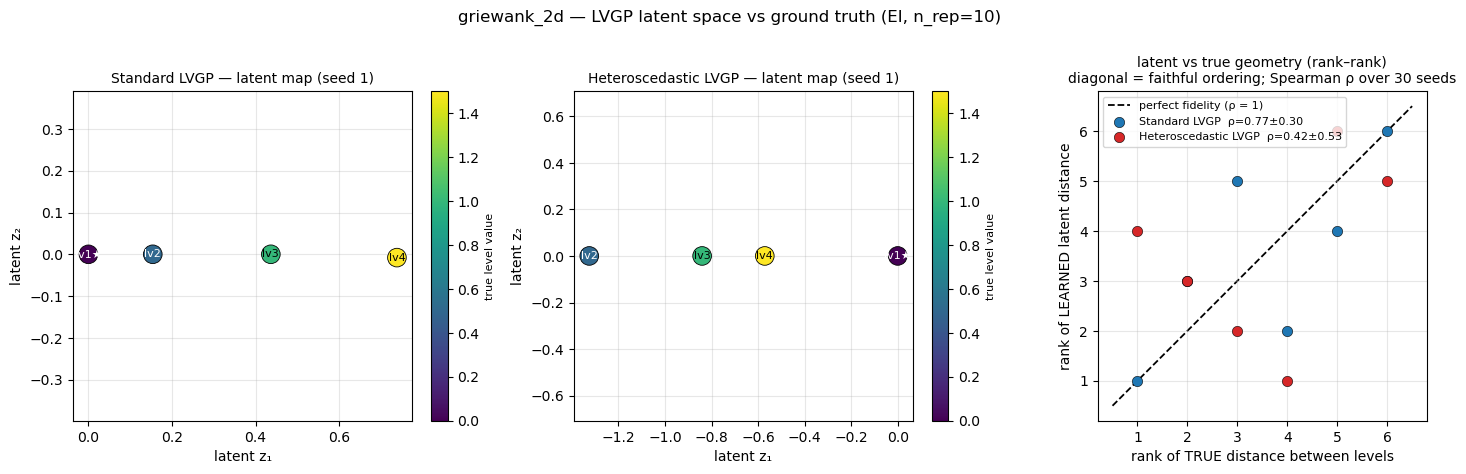

In [13]:
latent_space(grid, FOCUS, acf=ACF, param=PARAM, n_rep=N_REP, seed=1);

### Generate the same report for **every** problem → `plots/<problem>/`
Writes `overview.png` + `exploration.png` under `notebooks/plots/<problem>/` for each test problem, so you
have them as files without cluttering the notebook. `show=False` keeps the batch output clean.

In [14]:
all_problem_reports(grid, functions=FUNCS, save_root='plots',
                    acf=ACF, param=PARAM, n_rep=N_REP, ground_truth=GROUND_TRUTH,
                    seed=1, noise_aware_only=NOISE_AWARE_ONLY);


  wrote plots/ackley_2d/overview.png + exploration.png + by_acquisition.png + latent_space.png


  wrote plots/branin_hetero/overview.png + exploration.png + by_acquisition.png + latent_space.png


  wrote plots/griewank_2d/overview.png + exploration.png + by_acquisition.png + latent_space.png


  wrote plots/sixhump_camel/overview.png + exploration.png + by_acquisition.png + latent_space.png
